# Backpropagation From Scratch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1a
Write code that uses backpropagation for training the given neural network.


## Initialize Weights, Biases, and Structure of Neural Network
Define a neural network class, given that this is for a specific problem, it is find to hard code parameters.

In [ ]:
class NeuralNetwork:
  def __init__(self, x):
    # Initialize the weight and biases for theta_1 (2 to 2 nodes) and theta_2 (2 to 1 node)
    self.theta1 = np.random.uniform(0, 1, (2, 2))
    self.theta2 = np.random.uniform(0, 1, (1, 2))
    self.b1 = np.random.uniform(0, 1, (2, 1))
    self.b2 = np.random.uniform(0, 1, (1, 1))
    self.x = x

    # Set learning rate of 0.05
    self.gamma = 0.05

    # Output target
    self.y = np.array([[3]])

  def print_variables(self):
    # Print all variables with labels
    print("theta1:", self.theta1)
    print("theta2:", self.theta2)
    print("b1:", self.b1)
    print("b2:", self.b2)
    print("x:", self.x)
    print("y:", self.y)
    print("z1:", self.z1)
    print("a1:", self.a1)
    print("z2:", self.z2)
    print("a2:", self.a2)


  def activation(self, x):
    # Assuming ReLu given that it is regression but doesn't say which activation function
    return np.maximum(x, 0)

  def activation_derivative(self, x):
    # Derivative is just 1 if greater than 0 and 0 otherwise
    return np.where(x > 0, 1, 0)

  def squared_error(self, x):
    # Googled squared error loss formula
    return 0.5 * (self.y - x) ** 2

  def forward(self):
    # Pass through first layer
    self.z1 = np.dot(self.theta1, self.x) + self.b1
    self.a1 = self.activation(self.z1)

    # Pass through second layer
    self.z2 = np.dot(self.theta2, self.a1) + self.b2
    self.a2 = self.activation(self.z2)

    # Return the squared error loss
    return self.squared_error(self.a2)

  def backward(self):
    # Calculate the gradient of weights and biases for layer 2 to output
    delta2 = self.a2 - self.y
    dtheta2 = np.dot(delta2, self.a1.T)
    db2 = delta2

    # Calculate the gradient of weights and biases for layer 1
    delta1 = np.dot(self.theta2.T, delta2) * self.activation_derivative(self.z1)
    dtheta1 = np.dot(delta1, self.x.T)
    db1 = delta1

    # Update the weights and biases
    self.theta1 -= self.gamma * dtheta1
    self.theta2 -= self.gamma * dtheta2
    self.b1 -= self.gamma * db1
    self.b2 -= self.gamma * db2

# Empty array to store losses
losses = []

# Input sample
x = np.array([[2], [1]])

## Loop 50 times while using Backpropagation


In [ ]:
# Loop 50 times storing the loss values each iteration
NN = NeuralNetwork(x)
for _ in range(50):
  # Forward pass, and keep the resulting loss
  loss = NN.forward()
  losses.append(loss[0])

  # Backward Pass
  NN.backward()

# print(losses)
# NN.print_variables()

theta1: [[0.52012032 0.73493814]
 [0.73681975 0.11026477]]
theta2: [[0.60777548 0.56469068]]
b1: [[0.06786345]
 [0.61839525]]
b2: [[0.63622611]]
x: [[2]
 [1]]
y: [[3]]
z1: [[1.84304223]
 [2.20229953]]
a1: [[1.84304223]
 [2.20229953]]
z2: [[3.]]
a2: [[3.]]


## Plot
Plot the losses against each iteration.

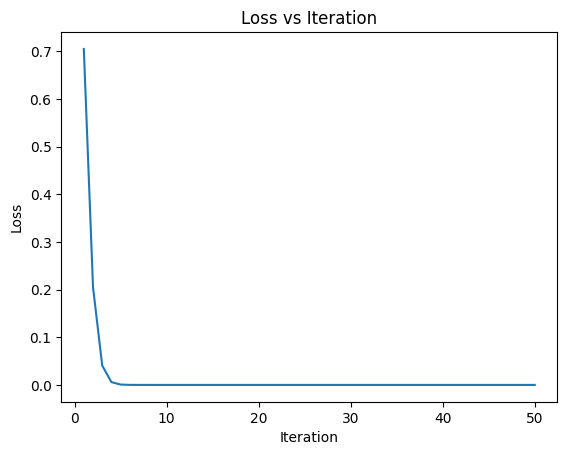

In [ ]:
# Plot the loss values against each iteration (the index + 1)
plt.plot(range(1, len(losses) + 1), losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs Iteration')
plt.show()